In [1]:

import cv2
import time 
import mediapipe as mp 

cap = cv2.VideoCapture(0)

mpHands = mp.solutions.hands
hands = mpHands.Hands()  
mpDraw = mp.solutions.drawing_utils

pTime = 0
cTime = 0

while True:
    success, img = cap.read()
    imgRGB = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    results = hands.process(imgRGB)
    print(results.multi_hand_landmarks)

    if results.multi_hand_landmarks:
        for handLms in results.multi_hand_landmarks:
            mpDraw.draw_landmarks(img, handLms, mpHands.HAND_CONNECTIONS)
            for id, lm in enumerate(handLms.landmark):
                h, w, c = img.shape
                cx, cy = int(lm.x * w), int(lm.y * h)
                cv2.putText(img, str(id), (cx, cy), cv2.FONT_HERSHEY_PLAIN, 1, (255, 0, 0), 2)
                print(f"id: {id}, x: {lm.x:.4f}, y: {lm.y:.4f}, z: {lm.z:.4f}")

                if id == 20: 
                    cv2.circle(img, (cx, cy), 9, (255, 0, 0), cv2.FILLED)

    cTime = time.time()
    fps = 1 / (cTime - pTime)
    pTime = cTime

    cv2.putText(img, f'FPS: {int(fps)}', (10, 30), cv2.FONT_HERSHEY_PLAIN, 2, (255, 0, 0), 2)

    cv2.imshow("Image", img)

    # 🔽 q tuşuna basınca çık
    if cv2.waitKey(1) & 0xFF == ord('q'):
        print("⏹️ Kamera durduruldu.")
        break

# 🔚 Kamera ve pencereyi serbest bırak
cap.release()
cv2.destroyAllWindows()


None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
None
⏹️ Kamera durduruldu.



0: 480x640 1 person, 171.0ms
Speed: 7.6ms preprocess, 171.0ms inference, 14.5ms postprocess per image at shape (1, 3, 480, 640)


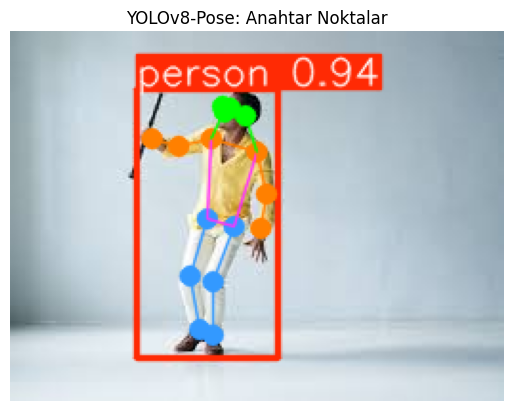

In [4]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# 1. POSE modelini yükle (yolov8n-pose en hafif versiyon)
model = YOLO("yolov8n-pose.pt")

# 2. Örnek görseli yükle
img_path = "Resim/vücut.jpeg"  # Buraya kendi resmini koy
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 3. Tahmin yap
results = model(img_rgb)

# 4. Tahminleri görsele çiz
annotated_frame = results[0].plot()

# 5. Sonucu göster
plt.imshow(annotated_frame)
plt.axis('off')
plt.title("YOLOv8-Pose: Anahtar Noktalar")
plt.show()


In [6]:
from ultralytics import YOLO
import cv2
import mediapipe as mp


# 1. YOLOv8 pose modelini yükle
model = YOLO("yolov8n-pose.pt")  # Dilersen yolov8m-pose.pt gibi daha güçlü model kullanabilirsin

# 2. Girdi videosu
video_path = "resim/pose1.mp4"  # Kendi videonu buraya koy
cap = cv2.VideoCapture(video_path)

# 3. Çıktı videosu ayarları
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
fps = cap.get(cv2.CAP_PROP_FPS)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
out = cv2.VideoWriter("pose_cikti.mp4", fourcc, fps, (w, h))

# 4. Her kareyi işle
while cap.isOpened():
    success, frame = cap.read()
    if not success:
        break

    # 5. POSE tahmini yap
    results = model(frame)

    # 6. Anahtar noktaları çiz
    annotated_frame = results[0].plot()

    # 7. Çizilmiş kareyi göster (istersen kaldırabilirsin)
    cv2.imshow("YOLOv8-Pose", annotated_frame)

    # 8. Yeni videoya kaydet
    out.write(annotated_frame)

    # q ile çık
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# 9. Temizlik
cap.release()
out.release()
cv2.destroyAllWindows()
print("✅ pose_cikti.mp4 oluşturuldu.")






0: 384x640 1 person, 85.8ms
Speed: 2.0ms preprocess, 85.8ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 87.3ms
Speed: 1.7ms preprocess, 87.3ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 77.9ms
Speed: 4.5ms preprocess, 77.9ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 73.3ms
Speed: 1.9ms preprocess, 73.3ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 64.6ms
Speed: 2.3ms preprocess, 64.6ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 72.8ms
Speed: 2.3ms preprocess, 72.8ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 67.3ms
Speed: 1.6ms preprocess, 67.3ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 61.2ms
Speed: 2.1ms preprocess, 61.2ms inference, 1.1ms postprocess per image at shape (1, 3, 38

In [9]:
import cv2

# 1. OpenCV'nin içinde gelen yüz algılama modeli (Haar Cascade)
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

video_path  = "resim/face1.mp4"  # Kendi videonu buraya koy 

# 2. Video yakalama
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    print("Video açılamadı!")
    exit()
# 3. Her kareyi oku ve yüzleri algıla


while True:
    ret, frame = cap.read()
    if not ret:
        break

    # 3. Griye çevir (Haar modeli için daha iyi sonuç)
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # 4. Yüzleri algıla
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

    # 5. Yüzlerin etrafına dikdörtgen çiz
    for (x, y, w, h) in faces:
        cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)

    # 6. Göster
    cv2.imshow("Yüz Algılama", frame)

    # 7. 'q' tuşuna basarak çık
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# 8. Temizlik
cap.release()
cv2.destroyAllWindows()


In [10]:
import cv2
import mediapipe as mp

# 1. MediaPipe modüllerini hazırla
mp_face_mesh = mp.solutions.face_mesh
mp_drawing = mp.solutions.drawing_utils

# 2. Giriş videosunu aç
video_path = "resim/face1.mp4"  # ← Kendi video dosyanın yolu
cap = cv2.VideoCapture(video_path)

# 3. Çıktı videosunu ayarla
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
fps = cap.get(cv2.CAP_PROP_FPS)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
out = cv2.VideoWriter("face_mesh_output.mp4", fourcc, fps, (w, h))

# 4. MediaPipe Face Mesh başlat
with mp_face_mesh.FaceMesh(
    static_image_mode=False,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
) as face_mesh:

    while cap.isOpened():
        success, frame = cap.read()
        if not success:
            break

        # BGR → RGB dönüşüm
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        # Yüz noktalarını tahmin et
        results = face_mesh.process(rgb_frame)

        # Yüz ağını çiz
        if results.multi_face_landmarks:
            for face_landmarks in results.multi_face_landmarks:
                mp_drawing.draw_landmarks(
                    image=frame,
                    landmark_list=face_landmarks,
                    connections=mp_face_mesh.FACEMESH_TESSELATION,
                    landmark_drawing_spec=None,
                    connection_drawing_spec=mp_drawing.DrawingSpec(color=(0, 255, 0), thickness=1, circle_radius=1)
                )

        # Ekranda göster (isteğe bağlı)
        cv2.imshow("Face Mesh", frame)

        # Videoya yaz
        out.write(frame)

        # q ile çık
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

# 5. Kaynakları temizle
cap.release()
out.release()
cv2.destroyAllWindows()
print("✅ face_mesh_output.mp4 oluşturuldu.")


✅ face_mesh_output.mp4 oluşturuldu.


In [2]:
import cv2
import numpy as np
from ultralytics import YOLO

def calculate_angle(a, b, c):
    """3 Noktadan açı hesaplar (b ortadadır)"""
    a, b, c = np.array(a), np.array(b), np.array(c)
    ba = a - b
    bc = c - b
    cosine = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-6)
    angle = np.arccos(np.clip(cosine, -1.0, 1.0))
    return np.degrees(angle)

# Model ve video
model = YOLO("yolov8n-pose.pt")
video_path = "resim/koşmak.mp4"
cap = cv2.VideoCapture(video_path)

# Video kaydetme ayarları
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
fps = cap.get(cv2.CAP_PROP_FPS)

# İlk kareyi okuyup boyutları belirle
success, frame = cap.read()
if not success:
    print("❌ Video okunamadı.")
    exit()

results = model(frame)
annotated = results[0].plot()

scale_percent = 50
width = int(annotated.shape[1] * scale_percent / 100)
height = int(annotated.shape[0] * scale_percent / 100)
dim = (width, height)
annotated = cv2.resize(annotated, dim, interpolation=cv2.INTER_AREA)

# VideoWriter'ı oluştur
out = cv2.VideoWriter("hareket_cikti.mp4", fourcc, fps, (width, height))

# İlk kareyi yeniden işlemek için video başa sarılır
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

# Video boyunca döngü
while cap.isOpened():
    success, frame = cap.read()
    if not success:
        break

    results = model(frame)
    annotated = results[0].plot()

    annotated = cv2.resize(annotated, dim, interpolation=cv2.INTER_AREA)

    for person in results[0].keypoints.data:
        keypoints = person[:, :2].cpu().numpy()

        try:
            # Sağ kalça, sağ diz, sağ ayak bileği
            kalca = tuple(keypoints[12])
            diz = tuple(keypoints[14])
            ayak = tuple(keypoints[16])
            bacak_acisi = calculate_angle(kalca, diz, ayak)

            # Sağ omuz, sağ dirsek, sağ bilek
            omuz = tuple(keypoints[6])
            dirsek = tuple(keypoints[8])
            bilek = tuple(keypoints[10])
            kol_acisi = calculate_angle(omuz, dirsek, bilek)

            # Hareket sınıflandırması (örnek kurallar)
            if bacak_acisi < 70 and kol_acisi < 90:
                hareket = "Oturuyor"
            elif 70 <= bacak_acisi <= 160 and 90 <= kol_acisi < 150:
                hareket = "Yuruyor"
            else:
                hareket = "Kosuyor"

        except Exception as e:
            hareket = "Tespit edilemedi"

        cv2.putText(annotated, hareket, (20, 60), cv2.FONT_HERSHEY_SIMPLEX,
                    1.3, (255, 255, 255), 3)

    out.write(annotated)
    cv2.imshow("Hareket Tespiti", annotated)
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

# Temizlik
cap.release()
out.release()
cv2.destroyAllWindows()
print("✅ hareket_cikti.mp4 oluşturuldu.")



0: 384x640 (no detections), 67.2ms
Speed: 2.6ms preprocess, 67.2ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 62.1ms
Speed: 3.8ms preprocess, 62.1ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 (no detections), 89.4ms
Speed: 3.3ms preprocess, 89.4ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 88.8ms
Speed: 2.9ms preprocess, 88.8ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 90.3ms
Speed: 4.5ms preprocess, 90.3ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 persons, 101.2ms
Speed: 6.5ms preprocess, 101.2ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 persons, 78.2ms
Speed: 4.6ms preprocess, 78.2ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 persons, 71.4ms
Speed: 4.1ms preprocess, 71.4ms inference, 0.8ms postprocess pe

In [7]:
import cv2
import numpy as np
from ultralytics import YOLO

def calculate_angle(a, b, c):
    """3 Noktadan açı hesaplar (b ortadadır)"""
    a, b, c = np.array(a), np.array(b), np.array(c)
    ba = a - b
    bc = c - b
    cosine = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-6)
    angle = np.arccos(np.clip(cosine, -1.0, 1.0))
    return np.degrees(angle)

# Model ve video
model = YOLO("yolov8n-pose.pt")
video_path = "resim/yürümek.mp4"
cap = cv2.VideoCapture(video_path)

# Video kaydetme ayarları
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
fps = cap.get(cv2.CAP_PROP_FPS)

# İlk kareyi okuyup boyutları belirle
success, frame = cap.read()
if not success:
    print("❌ Video okunamadı.")
    exit()

results = model(frame)
annotated = results[0].plot()

scale_percent = 25
width = int(annotated.shape[1] * scale_percent / 100)
height = int(annotated.shape[0] * scale_percent / 100)
dim = (width, height)
annotated = cv2.resize(annotated, dim, interpolation=cv2.INTER_AREA)

# VideoWriter'ı oluştur
out = cv2.VideoWriter("hareket_cikti.mp4", fourcc, fps, (width, height))

# İlk kareyi yeniden işlemek için video başa sarılır
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

# Video boyunca döngü
while cap.isOpened():
    success, frame = cap.read()
    if not success:
        break

    results = model(frame)
    annotated = results[0].plot()

    annotated = cv2.resize(annotated, dim, interpolation=cv2.INTER_AREA)

    for person in results[0].keypoints.data:
        keypoints = person[:, :2].cpu().numpy()

        try:
            # Sağ kalça, sağ diz, sağ ayak bileği
            kalca = tuple(keypoints[12])
            diz = tuple(keypoints[14])
            ayak = tuple(keypoints[16])
            bacak_acisi = calculate_angle(kalca, diz, ayak)

            # Sağ omuz, sağ dirsek, sağ bilek
            omuz = tuple(keypoints[6])
            dirsek = tuple(keypoints[8])
            bilek = tuple(keypoints[10])
            kol_acisi = calculate_angle(omuz, dirsek, bilek)

            # Hareket sınıflandırması (örnek kurallar)
            if bacak_acisi < 70 and kol_acisi < 90:
                hareket = "Oturuyor"
            elif 70 <= bacak_acisi <= 250 and 90 <= kol_acisi < 300:
                hareket = "Yuruyor"
            else:
                hareket = "Kosuyor"

        except Exception as e:
            hareket = "Tespit edilemedi"

        cv2.putText(annotated, hareket, (20, 60), cv2.FONT_HERSHEY_SIMPLEX,
                    1.3, (255, 255, 255), 3)

    out.write(annotated)
    cv2.imshow("Hareket Tespiti", annotated)
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

# Temizlik
cap.release()
out.release()
cv2.destroyAllWindows()
print("✅ hareket_cikti.mp4 oluşturuldu.")



0: 640x384 1 person, 62.1ms
Speed: 1.6ms preprocess, 62.1ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 1 person, 58.5ms
Speed: 3.6ms preprocess, 58.5ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 1 person, 83.9ms
Speed: 3.1ms preprocess, 83.9ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 1 person, 69.3ms
Speed: 3.7ms preprocess, 69.3ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 1 person, 60.5ms
Speed: 3.6ms preprocess, 60.5ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 1 person, 63.7ms
Speed: 3.6ms preprocess, 63.7ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 1 person, 60.8ms
Speed: 2.5ms preprocess, 60.8ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 1 person, 62.4ms
Speed: 4.0ms preprocess, 62.4ms inference, 0.7ms postprocess per image at shape (1, 3, 64

In [9]:
import cv2
import numpy as np
from ultralytics import YOLO

def calculate_angle(a, b, c):
    a, b, c = np.array(a), np.array(b), np.array(c)
    ba = a - b
    bc = c - b
    cosine = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-6)
    angle = np.arccos(np.clip(cosine, -1.0, 1.0))
    return np.degrees(angle)

# Model ve video
model = YOLO("yolov8n-pose.pt")
video_path = "resim/oturmak.mp4"  # kendi videonu buraya koy
cap = cv2.VideoCapture(video_path)

# FPS ve ilk kare için boyutlar
fps = cap.get(cv2.CAP_PROP_FPS)
success, frame = cap.read()
if not success:
    print("❌ Video yüklenemedi")
    exit()

results = model(frame)
annotated = results[0].plot()

scale_percent = 25
width = int(annotated.shape[1] * scale_percent / 100)
height = int(annotated.shape[0] * scale_percent / 100)
dim = (width, height)
annotated = cv2.resize(annotated, dim, interpolation=cv2.INTER_AREA)

# VideoWriter
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter("otur_kalk_cikti.mp4", fourcc, fps, (width, height))
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

while cap.isOpened():
    success, frame = cap.read()
    if not success:
        break

    results = model(frame)
    annotated = results[0].plot()
    annotated = cv2.resize(annotated, dim, interpolation=cv2.INTER_AREA)

    for person in results[0].keypoints.data:
        keypoints = person[:, :2].cpu().numpy()
        try:
            # Sağ bacak
            kalca = tuple(keypoints[12])
            diz = tuple(keypoints[14])
            ayak = tuple(keypoints[16])
            bacak_aci = calculate_angle(kalca, diz, ayak)

            # Sağ kol
            omuz = tuple(keypoints[6])
            dirsek = tuple(keypoints[8])
            bilek = tuple(keypoints[10])
            kol_aci = calculate_angle(omuz, dirsek, bilek)

            # Sınıflandırma
            if bacak_aci < 200 and kol_aci <200:
                durum = "Oturuyor"
            else:
                durum = "Ayakta (Kalkti)"

        except:
            durum = "Tespit edilemedi"

        # Ekrana yaz
        cv2.putText(annotated, durum, (20, 60), cv2.FONT_HERSHEY_SIMPLEX,
                    1.3, (255, 255, 255), 3)

    out.write(annotated)
    cv2.imshow("Oturma/Kalkma Tespiti", annotated)
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
out.release()
cv2.destroyAllWindows()
print("✅ otur_kalk_cikti.mp4 oluşturuldu.")



0: 384x640 1 person, 85.2ms
Speed: 3.0ms preprocess, 85.2ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 78.7ms
Speed: 2.7ms preprocess, 78.7ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 75.4ms
Speed: 2.8ms preprocess, 75.4ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 75.5ms
Speed: 2.6ms preprocess, 75.5ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 80.5ms
Speed: 2.6ms preprocess, 80.5ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 88.1ms
Speed: 2.5ms preprocess, 88.1ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 84.5ms
Speed: 3.0ms preprocess, 84.5ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 86.3ms
Speed: 2.6ms preprocess, 86.3ms inference, 1.4ms postprocess per image at shape (1, 3, 38

In [ ]:
import cv2
import numpy as np
from ultralytics import YOLO

# 📌 1. Açı hesaplama fonksiyonu
def calculate_angle(a, b, c):
    a, b, c = np.array(a), np.array(b), np.array(c)
    ba = a - b
    bc = c - b
    cosine_angle = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-6)
    angle = np.arccos(np.clip(cosine_angle, -1.0, 1.0))
    return np.degrees(angle)

# 📌 2. YOLOv8 pose modeli yükleniyor
model = YOLO("yolov8n-pose.pt")

# 📌 3. Video dosyasını aç
video_path = "resim/kosucu.mp4"
cap = cv2.VideoCapture(video_path)

# 📌 4. FPS ve video boyutları
fps = cap.get(cv2.CAP_PROP_FPS)
if fps == 0:
    print("⚠️ FPS tespit edilemedi. Varsayılan 25 olarak ayarlandı.")
    fps = 25
frame_time = 1 / fps

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH) * 0.5)
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT) * 0.5)

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter("hareket_analiz.mp4", fourcc, fps, (width, height))

# 📌 5. Varsayılan analiz parametreleri
stride_length = 1.5           # Ortalama adım uzunluğu (m)
steps_per_second = 2          # Ortalama adım sayısı (saniyede)

yurume_sure = kosma_sure = 0
yurume_mesafe = kosma_mesafe = 0

# 📌 6. Videoyu kare kare işle
while cap.isOpened():
    success, frame = cap.read()
    if not success:
        break

    results = model(frame)
    annotated = results[0].plot()
    annotated = cv2.resize(annotated, (width, height))

    for person in results[0].keypoints.data:
        keypoints = person[:, :2].cpu().numpy()

        try:
            kalca = tuple(keypoints[24])  # Sağ kalça
            diz = tuple(keypoints[26])    # Sağ diz
            ayak = tuple(keypoints[28])   # Sağ ayak bileği

            angle = calculate_angle(kalca, diz, ayak)

            if 90 < angle <= 160:
                hareket = "Yürüyor"
                yurume_sure += frame_time
                yurume_mesafe += stride_length * steps_per_second * frame_time
            elif angle > 160:
                hareket = "Koşuyor"
                kosma_sure += frame_time
                kosma_mesafe += stride_length * steps_per_second * frame_time
            else:
                hareket = "Oturuyor"
        except:
            hareket = "Tespit Edilemedi"

        cv2.putText(annotated, f"{hareket}", (20, 60),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.3, (255, 255, 255), 2)

    out.write(annotated)
    cv2.imshow("Hareket Analizi", annotated)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

# 📌 7. Temizlik
cap.release()
out.release()
cv2.destroyAllWindows()

# 📌 8. Özet Bilgiler
print(f"🚶 Yürüme süresi: {yurume_sure:.2f} sn - Mesafe: {yurume_mesafe:.2f} m")
print(f"🏃 Koşma süresi: {kosma_sure:.2f} sn - Mesafe: {kosma_mesafe:.2f} m")

# 📌 9. 8 km hedef analizi
hedef_km = 8
eksik_km = max(0, hedef_km - kosma_mesafe / 1000)
eksik_dk = (eksik_km * 1000) / (stride_length * steps_per_second * 60)
print(f"🎯 8 km hedefi için kalan süre: {eksik_dk:.2f} dakika")



0: 384x640 1 person, 143.6ms
Speed: 7.6ms preprocess, 143.6ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 110.5ms
Speed: 3.5ms preprocess, 110.5ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 99.8ms
Speed: 2.9ms preprocess, 99.8ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 97.6ms
Speed: 2.7ms preprocess, 97.6ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 89.5ms
Speed: 4.0ms preprocess, 89.5ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 115.1ms
Speed: 4.1ms preprocess, 115.1ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 88.8ms
Speed: 4.0ms preprocess, 88.8ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 91.1ms
Speed: 1.9ms preprocess, 91.1ms inference, 1.5ms postprocess per image at shape (1,